# Figure 6: Patient-Level Confusion Matrices

Aggregated patient-level confusion matrices for all evaluated models (5-fold combined).

**Manuscript reference:** Figure 6A (SegFormer), Figure 6B (Mask R-CNN), Figure 6C (YOLOv8-Seg)

## Figure 6A & 6B: SegFormer + Mask R-CNN Confusion Matrices

# Fold Bazlı Confusion Matrix Görselleştirmesi (FIXED)

Bu notebook her fold için ayrı confusion matrix oluşturur ve 2x3 grid'de gösterir:
- **(a)** FOLD_1
- **(b)** FOLD_2
- **(c)** FOLD_3
- **(d)** FOLD_4
- **(e)** FOLD_5
- **(f)** Tüm Foldlar Birleştirilmiş

**FİX:** Patient ID'lerden slice numaraları çıkarılarak gerçek patient-level aggregation yapılıyor.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.metrics import confusion_matrix
import warnings
warnings.filterwarnings('ignore')

# Publication-quality plotting
plt.style.use('seaborn-v0_8-paper')
sns.set_palette("husl")
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.size'] = 10

In [2]:
# Konfigürasyon
BASE_DIR = Path('/home/zera/Desktop/data_fold/folds/folds')
OUTPUT_DIR = BASE_DIR / 'output'
FOLDS = ['FOLD_1', 'FOLD_2', 'FOLD_3', 'FOLD_4', 'FOLD_5']

# Çıktı klasörü
FIGURES_DIR = Path('/home/zera/Desktop/data_fold/test_evaluation_figures')
FIGURES_DIR.mkdir(exist_ok=True)

print(f"Base directory: {BASE_DIR}")
print(f"Output directory: {OUTPUT_DIR}")
print(f"Figures directory: {FIGURES_DIR}")

Base directory: /home/zera/Desktop/data_fold/folds/folds
Output directory: /home/zera/Desktop/data_fold/folds/folds/output
Figures directory: /home/zera/Desktop/data_fold/test_evaluation_figures


In [3]:
def load_predictions_for_fold(fold_name, run_number):
    """
    Belirli bir fold ve run için prediction verisini yükle.
    """
    pred_path = OUTPUT_DIR / fold_name / f'run_{run_number}' / 'final' / 'fold_test_predictions' / 'predictions.csv'
    
    if not pred_path.exists():
        print(f"Warning: {pred_path} not found")
        return None
    
    return pd.read_csv(pred_path)

def aggregate_patient_level_classification(predictions_df, threshold=0.5):
    """
    Slice-level tahminleri hasta bazında topla.
    Hasta-level probability = slice-level probability'lerin ortalaması.
    
    NOT: patient_id formatı '005_R_P_001' şeklinde. Son 3 hane slice numarası.
    Gerçek patient ID için son _XXX kısmını çıkarıyoruz.
    """
    # Patient ID'den slice numarasını çıkar (son _XXX'i kaldır)
    predictions_df = predictions_df.copy()
    predictions_df['actual_patient_id'] = predictions_df['patient_id'].str.rsplit('_', n=1).str[0]
    
    patient_data = []
    
    for patient_id in predictions_df['actual_patient_id'].unique():
        patient_slices = predictions_df[predictions_df['actual_patient_id'] == patient_id]
        
        # Slice'lar arası probability ortalaması
        mean_prob = patient_slices['arthrit_prob'].mean()
        
        # Threshold uygula
        pred_label = 'arthrit' if mean_prob >= threshold else 'control'
        
        # Gerçek label (aynı hasta için tüm slice'larda tutarlı olmalı)
        true_label = patient_slices['true_group'].iloc[0]
        
        patient_data.append({
            'patient_id': patient_id,
            'true_label': true_label,
            'pred_label': pred_label,
            'mean_probability': mean_prob,
            'num_slices': len(patient_slices),
            'true_class_numeric': 1 if true_label == 'arthrit' else 0,
            'pred_class_numeric': 1 if pred_label == 'arthrit' else 0
        })
    
    return pd.DataFrame(patient_data)

print("Fonksiyonlar yüklendi.")

Fonksiyonlar yüklendi.


## Fold Bazlı Confusion Matrix Görselleştirmesi

FOLD_1: 13 patients (was 130 slices)
FOLD_2: 13 patients (was 130 slices)
FOLD_3: 13 patients (was 131 slices)
FOLD_4: 13 patients (was 131 slices)
FOLD_5: 13 patients (was 133 slices)

Total patients across all folds: 65

Figure 3.4 saved to: /home/zera/Desktop/data_fold/test_evaluation_figures/Figure_3.4_Confusion_Matrix_Per_Fold.png


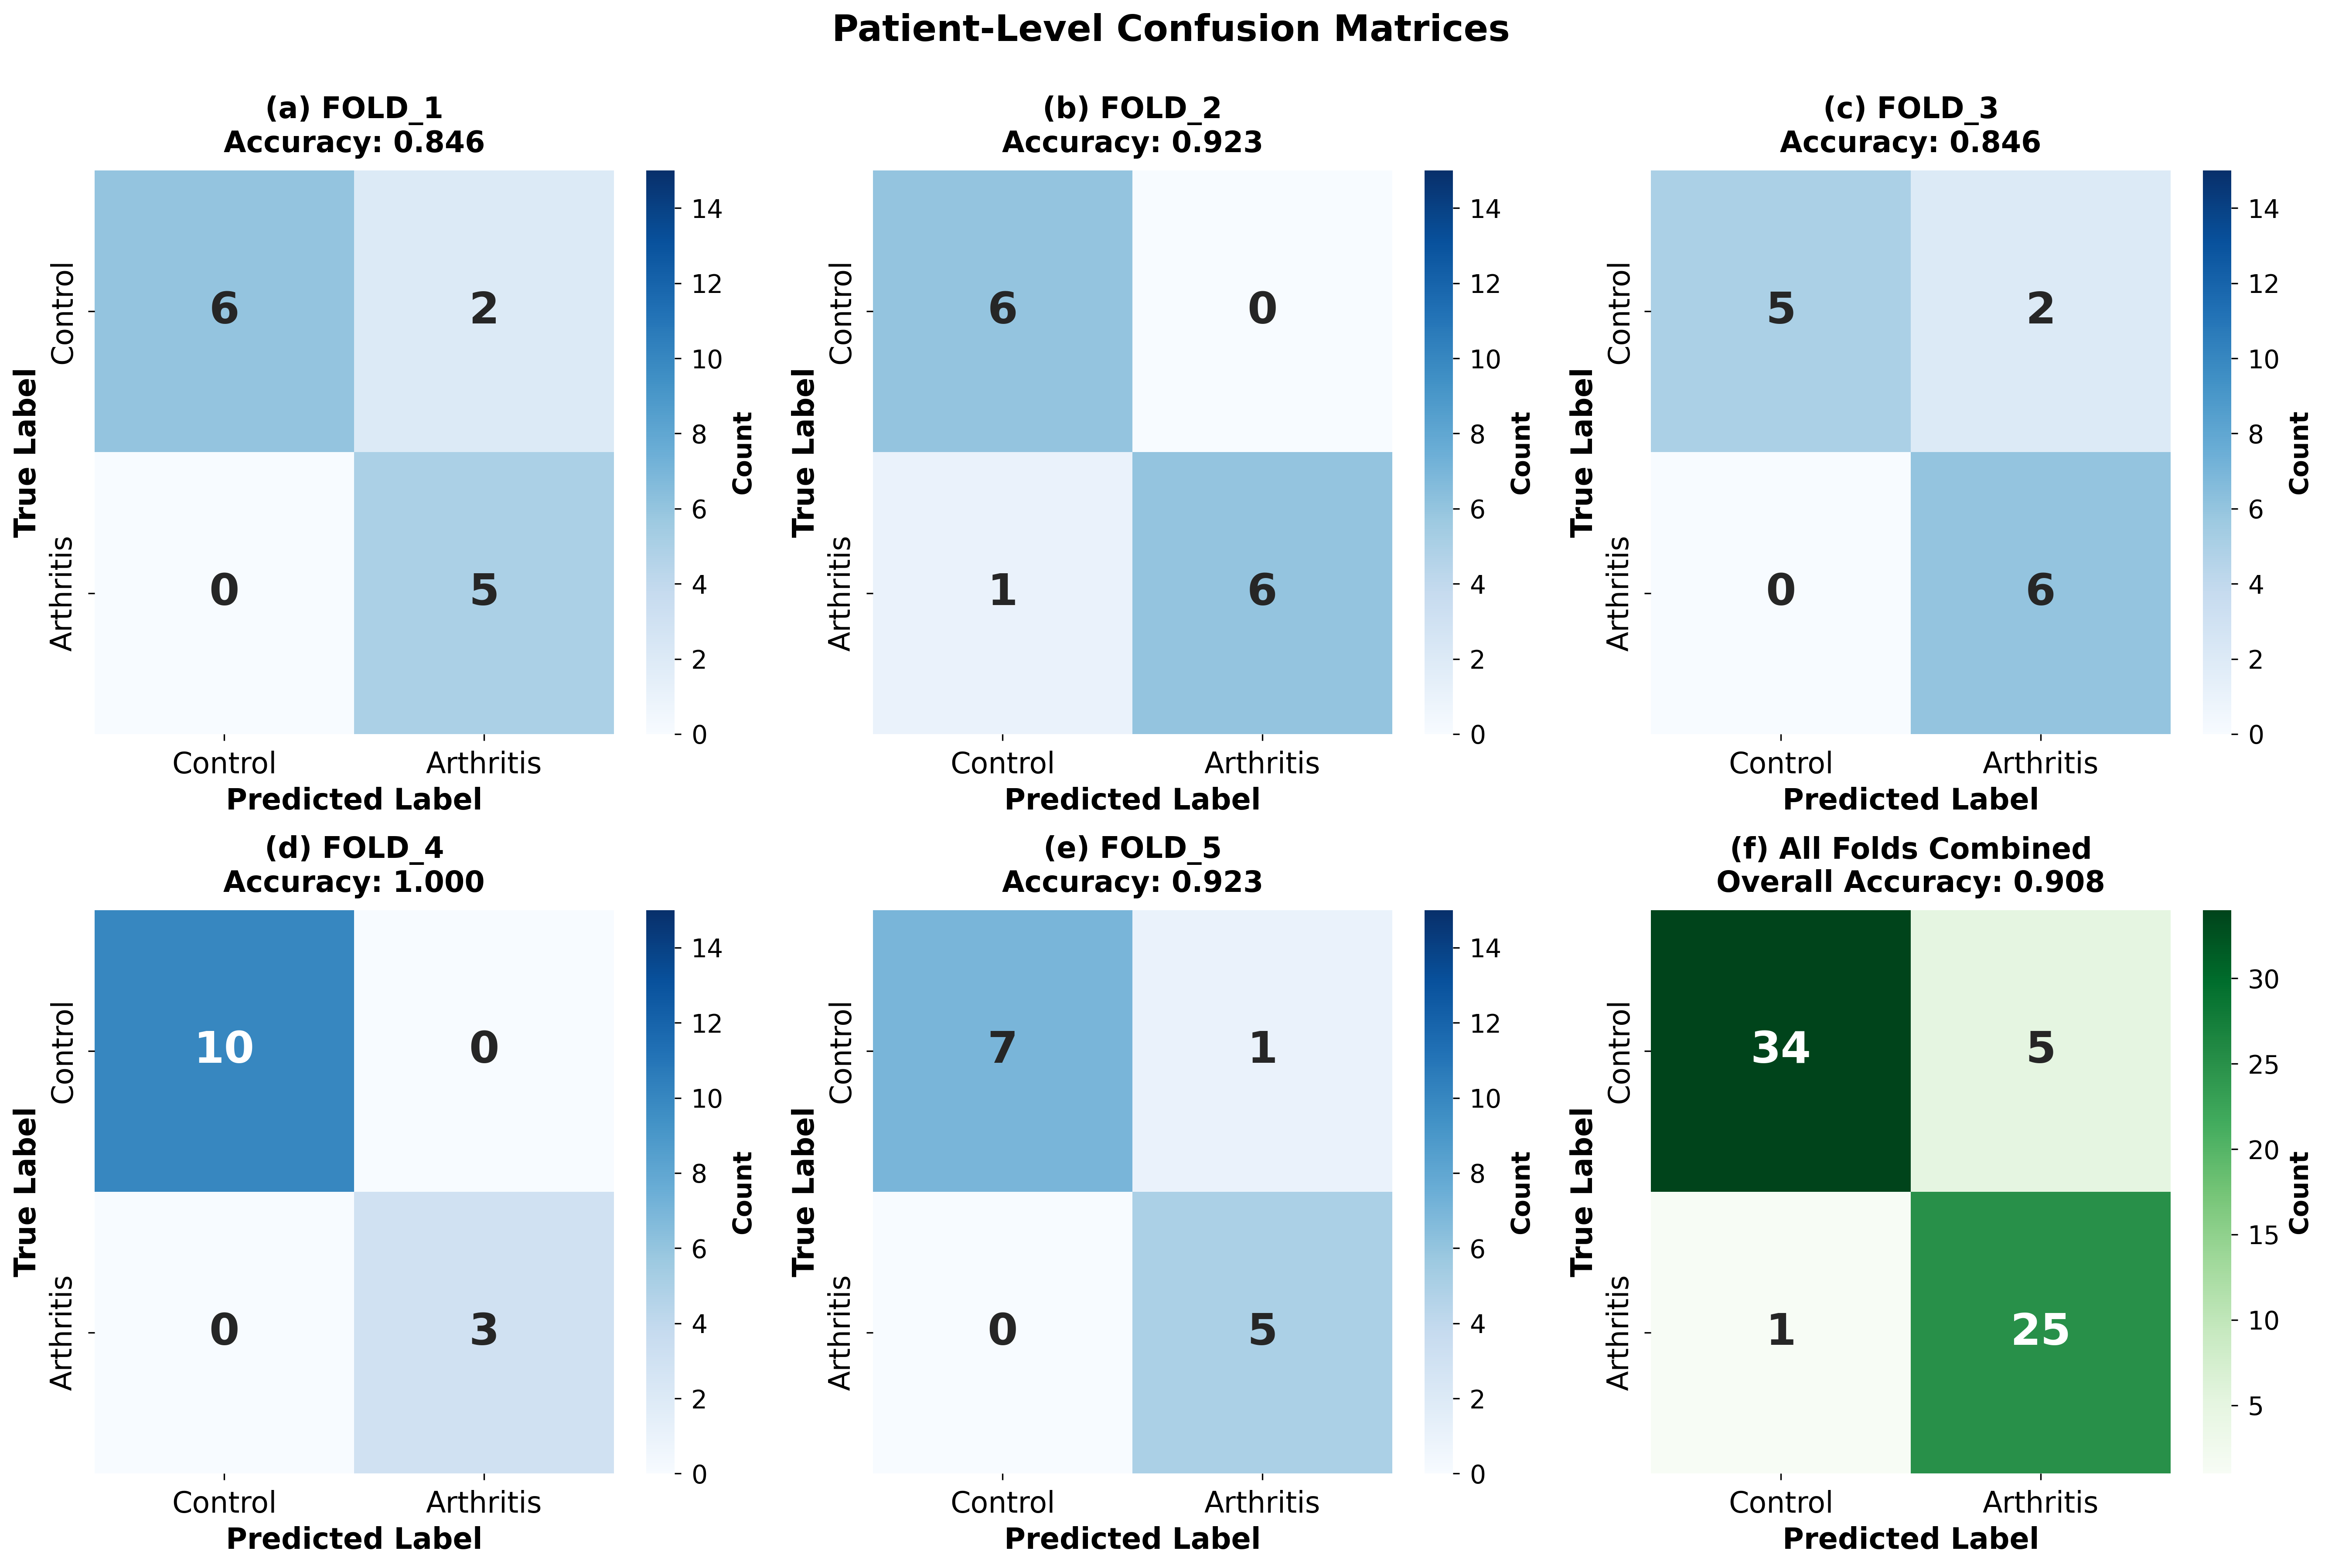

In [6]:
def plot_confusion_matrix_all_folds():
    ANNOT_SIZE = 24
    TICK_SIZE = 16
    LABEL_SIZE = 16
    TITLE_SIZE = 16
    SUPTITLE_SIZE = 20
    CBAR_TICK_SIZE = 14
    CBAR_LABEL_SIZE = 14

    class_names = ['Control', 'Arthritis']
    cm_labels = [0, 1]

    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    axes = axes.ravel()

    fold_labels = ['(a)', '(b)', '(c)', '(d)', '(e)']

    all_y_true = []
    all_y_pred = []

    for idx, fold in enumerate(FOLDS[:5]):
        pred_df = load_predictions_for_fold(fold, 1)
        ax = axes[idx]

        if pred_df is None or len(pred_df) == 0:
            ax.axis('off')
            continue

        patient_df = aggregate_patient_level_classification(pred_df)

        print(f"{fold}: {len(patient_df)} patients (was {len(pred_df)} slices)")

        y_true = patient_df['true_class_numeric'].to_numpy()
        y_pred = patient_df['pred_class_numeric'].to_numpy()

        all_y_true.extend(y_true.tolist())
        all_y_pred.extend(y_pred.tolist())

        cm = confusion_matrix(y_true, y_pred, labels=cm_labels)

        hm = sns.heatmap(
            cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names,
            cbar_kws={'label': 'Count'},
            ax=ax,
            annot_kws={'size': ANNOT_SIZE, 'weight': 'bold'},
            vmin=0, vmax=15
        )

        total = cm.sum()
        accuracy = (np.trace(cm) / total) if total > 0 else 0.0

        ax.set_xlabel('Predicted Label', fontsize=LABEL_SIZE, fontweight='bold')
        ax.set_ylabel('True Label', fontsize=LABEL_SIZE, fontweight='bold')
        ax.set_title(
            f'{fold_labels[idx]} {fold}\nAccuracy: {accuracy:.3f}',
            fontsize=TITLE_SIZE, fontweight='bold', pad=10
        )

        ax.tick_params(axis='x', labelsize=TICK_SIZE)
        ax.tick_params(axis='y', labelsize=TICK_SIZE)

        cbar = hm.collections[0].colorbar
        cbar.ax.tick_params(labelsize=CBAR_TICK_SIZE)
        cbar.set_label('Count', fontsize=CBAR_LABEL_SIZE, fontweight='bold')

    ax = axes[5]

    if len(all_y_true) == 0:
        ax.axis('off')
        plt.suptitle('Patient-Level Confusion Matrices', fontsize=SUPTITLE_SIZE, fontweight='bold', y=0.995)
        plt.tight_layout(rect=[0, 0, 1, 0.99])
        plt.show()
        return None, None

    print(f"\nTotal patients across all folds: {len(all_y_true)}")

    cm_all = confusion_matrix(all_y_true, all_y_pred, labels=cm_labels)

    hm_all = sns.heatmap(
        cm_all, annot=True, fmt='d', cmap='Greens',
        xticklabels=class_names,
        yticklabels=class_names,
        cbar_kws={'label': 'Count'},
        ax=ax,
        annot_kws={'size': ANNOT_SIZE, 'weight': 'bold'}
    )

    total_all = cm_all.sum()
    accuracy_all = (np.trace(cm_all) / total_all) if total_all > 0 else 0.0

    ax.set_xlabel('Predicted Label', fontsize=LABEL_SIZE, fontweight='bold')
    ax.set_ylabel('True Label', fontsize=LABEL_SIZE, fontweight='bold')
    ax.set_title(
        f'(f) All Folds Combined\nOverall Accuracy: {accuracy_all:.3f}',
        fontsize=TITLE_SIZE, fontweight='bold', pad=10
    )

    ax.tick_params(axis='x', labelsize=TICK_SIZE)
    ax.tick_params(axis='y', labelsize=TICK_SIZE)

    cbar = hm_all.collections[0].colorbar
    cbar.ax.tick_params(labelsize=CBAR_TICK_SIZE)
    cbar.set_label('Count', fontsize=CBAR_LABEL_SIZE, fontweight='bold')

    plt.suptitle('Patient-Level Confusion Matrices', fontsize=SUPTITLE_SIZE, fontweight='bold', y=0.995)
    plt.tight_layout(rect=[0, 0, 1, 0.99])

    output_path = FIGURES_DIR / 'Figure_3.4_Confusion_Matrix_Per_Fold.png'
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    print(f"\nFigure 3.4 saved to: {output_path}")
    plt.show()

    return cm_all, accuracy_all


cm_combined, acc_combined = plot_confusion_matrix_all_folds()


## Özet İstatistikler

In [5]:
print("\n" + "="*60)
print("COMBINED CONFUSION MATRIX (All Folds)")
print("="*60)
print(cm_combined)
print(f"\nOverall Accuracy: {acc_combined:.4f}")
print(f"\nFigure saved to: {FIGURES_DIR / 'Figure_3.4_Confusion_Matrix_Per_Fold.png'}")


COMBINED CONFUSION MATRIX (All Folds)
[[34  5]
 [ 1 25]]

Overall Accuracy: 0.9077

Figure saved to: /home/zera/Desktop/data_fold/test_evaluation_figures/Figure_3.4_Confusion_Matrix_Per_Fold.png


## Figure 6C: YOLOv8-Seg Confusion Matrix

# YOLO Patient-Level Test Evaluation

Bu notebook, test goruntulerini hasta bazinda gruplayarak siniflandirma ve segmentasyon tablolarini uretir.

Temel duzeltme:
- `image_005_R_P_001.png`
- `image_005_R_P_002.png`

ayri hasta degil, tek hasta olarak `005_R_P` seklinde gruplanir.

Uretilen ciktilar:
- `artifacts/fold_{id}/test_eval_fixed/*`
- `artifacts/test_classification_table.csv`
- `artifacts/test_segmentation_table.csv`
- `artifacts/test_classification_table_fixed.csv`
- `artifacts/test_segmentation_table_fixed.csv`


In [1]:
from types import SimpleNamespace

CONFIG = SimpleNamespace(
    root_folds_dir="folds/folds",
    artifacts_dir="artifacts",
    selected_folds=None,      # ornek: [1] veya [1, 3]
    run_all_folds=True,
    imgsz=640,
    pred_conf=0.005,
    pred_iou=0.60,
    mask_conf_thr=0.30,
    mask_bin_thr=0.50,
    decision_thr=0.25,
    expected_patients=13,     # 0 yaparsan kontrol kapanir
    output_subdir="test_eval_fixed",
    table_digits=2,
)

CONFIG


namespace(root_folds_dir='folds/folds',
          artifacts_dir='artifacts',
          selected_folds=None,
          run_all_folds=True,
          imgsz=640,
          pred_conf=0.005,
          pred_iou=0.6,
          mask_conf_thr=0.3,
          mask_bin_thr=0.5,
          decision_thr=0.25,
          expected_patients=13,
          output_subdir='test_eval_fixed',
          table_digits=2)

In [2]:
import csv
import json
import math
import re
from pathlib import Path
from typing import Dict, Iterable, List, Optional, Tuple

import matplotlib.pyplot as plt
import numpy as np
import torch
from PIL import Image, ImageDraw, ImageFile
from ultralytics import YOLO

ImageFile.LOAD_TRUNCATED_IMAGES = True

try:
    import cv2  # type: ignore
    CV2_OK = True
except Exception:
    CV2_OK = False

IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}
ROI_EXTS = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff", ".txt"}
ARTHRITIS_CLS_ID = 1


def device_setup() -> str:
    if torch.cuda.is_available():
        torch.cuda.set_device(0)
        return "0"
    return "cpu"


def extract_fold_id(name: str) -> Optional[int]:
    match = re.search(r"(?i)fold[_ -]*(\d+)", name)
    return int(match.group(1)) if match else None


def find_folds(root_dir: Path, selected_ids: Optional[Iterable[int]] = None) -> List[Tuple[int, Path]]:
    selected = set(selected_ids or [])
    folds: List[Tuple[int, Path]] = []
    for path in sorted(root_dir.iterdir(), key=lambda p: p.name.lower()):
        if not path.is_dir():
            continue
        fold_id = extract_fold_id(path.name)
        if fold_id is None:
            continue
        if selected and fold_id not in selected:
            continue
        folds.append((fold_id, path))
    folds.sort(key=lambda item: item[0])
    return folds


def has_any_images(path: Path) -> bool:
    if not path.is_dir():
        return False
    return any(p.is_file() and p.suffix.lower() in IMG_EXTS for p in path.iterdir())


def resolve_images_only_dir(base: Path) -> Path:
    if (base / "images").is_dir():
        return base / "images"
    return base


def find_test_images_dir(fold_dir: Path) -> Optional[Path]:
    candidates = [
        fold_dir / "test" / "darkened_plgn",
        fold_dir / "test" / "darkened",
        fold_dir / "test" / "images",
        fold_dir / "test",
    ]
    for candidate in candidates:
        if candidate.is_dir():
            resolved = resolve_images_only_dir(candidate)
            if has_any_images(resolved):
                return resolved

    test_root = fold_dir / "test"
    if test_root.is_dir():
        for path in sorted(test_root.rglob("*"), key=lambda p: p.as_posix().lower()):
            if path.is_dir() and "roi" not in path.name.lower():
                resolved = resolve_images_only_dir(path)
                if has_any_images(resolved):
                    return resolved
    return None


def resolve_weights_path(artifacts_dir: Path, fold_id: int) -> Optional[Path]:
    candidates = [
        artifacts_dir / f"fold_{fold_id}" / "best.pt",
        Path("runs") / "segment" / f"train_FOLD_{fold_id}_medikal" / "weights" / "best.pt",
        Path("runs") / "segment" / f"train_FOLD_{fold_id}" / "weights" / "best.pt",
    ]
    for candidate in candidates:
        if candidate.exists():
            return candidate
    return None


def normalize_stem(stem: str) -> str:
    value = stem.strip().lower().replace("-", "_")
    for prefix in ("image_", "img_", "mask_", "roi_", "gt_"):
        if value.startswith(prefix):
            value = value[len(prefix):]
    while "__" in value:
        value = value.replace("__", "_")
    return value.strip("_")


def extract_patient_id_from_stem(stem: str) -> str:
    normalized = normalize_stem(stem)

    match = re.match(r"^(\d+_[lr]_[pc])_(\d+)$", normalized, flags=re.IGNORECASE)
    if match:
        return match.group(1).upper()

    match = re.match(r"^(.+?)_(\d+)$", normalized)
    if match:
        return match.group(1).upper()

    return normalized.upper()


def extract_patient_id(path: Path) -> str:
    return extract_patient_id_from_stem(path.stem)


def gt_from_patient_id(patient_id: str) -> Optional[int]:
    upper = patient_id.upper()
    if upper.endswith("_P"):
        return 1
    if upper.endswith("_C"):
        return 0
    return None


def gt_from_filename(img_path: Path) -> Optional[int]:
    gt = gt_from_patient_id(extract_patient_id(img_path))
    if gt is not None:
        return gt

    upper = img_path.stem.upper()
    if re.search(r"(^|_)P(_|$)", upper):
        return 1
    if re.search(r"(^|_)C(_|$)", upper):
        return 0
    return None


def build_roi_index(roi_dir: Path) -> Dict[str, Path]:
    files = [p for p in roi_dir.rglob("*") if p.is_file() and p.suffix.lower() in ROI_EXTS]
    index: Dict[str, Path] = {}
    for path in sorted(files, key=lambda p: p.as_posix().lower()):
        key = normalize_stem(path.stem)
        if key not in index:
            index[key] = path
    return index


def find_roi_for_image(img_path: Path, roi_index: Dict[str, Path]) -> Optional[Path]:
    image_key = normalize_stem(img_path.stem)
    if image_key in roi_index:
        return roi_index[image_key]

    patient_key = image_key
    match = re.match(r"^(.+?)_(\d+)$", image_key)
    if match:
        patient_key = match.group(1)

    roi_candidates = (
        patient_key + "_" + image_key.rsplit("_", 1)[-1],
        "mask_" + image_key,
        "mask_" + patient_key + "_" + image_key.rsplit("_", 1)[-1],
    )
    for candidate in roi_candidates:
        normalized = normalize_stem(candidate)
        if normalized in roi_index:
            return roi_index[normalized]
    return None


def safe_open_image(path: Path) -> Optional[Image.Image]:
    try:
        image = Image.open(path)
        image.load()
        return image
    except Exception:
        return None


def safe_open_mask_as_array(mask_path: Path, target_wh: Tuple[int, int]) -> Optional[np.ndarray]:
    width, height = target_wh
    try:
        mask = Image.open(mask_path).convert("L")
        if mask.size != (width, height):
            mask = mask.resize((width, height), resample=Image.NEAREST)
        array = np.array(mask)
        return (array > 0).astype(np.uint8)
    except Exception:
        pass

    if CV2_OK:
        try:
            mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
            if mask is None:
                return None
            if (mask.shape[1], mask.shape[0]) != (width, height):
                mask = cv2.resize(mask, (width, height), interpolation=cv2.INTER_NEAREST)
            return (mask > 0).astype(np.uint8)
        except Exception:
            return None
    return None


def load_roi_mask(img_path: Path, roi_path: Path) -> Optional[np.ndarray]:
    image = safe_open_image(img_path)
    if image is None:
        return None
    width, height = image.size

    if roi_path.suffix.lower() != ".txt":
        return safe_open_mask_as_array(roi_path, (width, height))

    try:
        lines = roi_path.read_text(encoding="utf-8", errors="ignore").splitlines()
    except Exception:
        return None

    canvas = Image.new("1", (width, height), 0)
    draw = ImageDraw.Draw(canvas)
    for line in lines:
        parts = line.strip().split()
        if len(parts) < 7:
            continue
        coords: List[float] = []
        valid = True
        for token in parts[1:]:
            try:
                coords.append(float(token))
            except Exception:
                valid = False
                break
        if not valid or len(coords) < 6 or len(coords) % 2 != 0:
            continue

        polygon = []
        for idx in range(0, len(coords), 2):
            polygon.append((coords[idx] * width, coords[idx + 1] * height))
        if len(polygon) >= 3:
            draw.polygon(polygon, outline=1, fill=1)

    return np.array(canvas, dtype=np.uint8)


def arthritis_score_from_result(result) -> float:
    boxes = getattr(result, "boxes", None)
    try:
        if boxes is None or getattr(boxes, "conf", None) is None or getattr(boxes, "cls", None) is None or len(boxes) == 0:
            return 0.0
        confs = boxes.conf.detach().cpu().numpy().astype(float)
        classes = boxes.cls.detach().cpu().numpy().astype(int)
        arthritis_mask = classes == int(ARTHRITIS_CLS_ID)
        if arthritis_mask.any():
            return float(np.max(confs[arthritis_mask]))
    except Exception:
        pass
    return 0.0


def pred_mask_from_result(result, target_hw: Tuple[int, int], mask_conf_thr: float, mask_bin_thr: float) -> np.ndarray:
    height, width = target_hw
    masks = getattr(result, "masks", None)
    boxes = getattr(result, "boxes", None)

    if masks is None or getattr(masks, "data", None) is None:
        return np.zeros((height, width), dtype=np.uint8)

    try:
        mask_data = masks.data.detach().float().cpu().numpy()
    except Exception:
        mask_data = np.asarray(masks.data)

    if mask_data.ndim != 3 or mask_data.shape[0] == 0:
        return np.zeros((height, width), dtype=np.uint8)

    keep = np.ones(mask_data.shape[0], dtype=bool)
    try:
        if boxes is not None and getattr(boxes, "conf", None) is not None and len(boxes) == mask_data.shape[0]:
            confs = boxes.conf.detach().cpu().numpy().astype(float)
            keep &= confs >= float(mask_conf_thr)
    except Exception:
        pass

    if not keep.any():
        return np.zeros((height, width), dtype=np.uint8)

    union = (mask_data[keep] > float(mask_bin_thr)).any(axis=0).astype(np.uint8)
    if union.shape != (height, width):
        union_img = Image.fromarray((union * 255).astype(np.uint8))
        union_img = union_img.resize((width, height), resample=Image.NEAREST)
        union = (np.array(union_img) > 0).astype(np.uint8)
    return union


def dice_iou_pixel(gt_mask: np.ndarray, pred_mask: np.ndarray) -> Tuple[float, float, float]:
    gt_mask = (gt_mask > 0).astype(np.uint8)
    pred_mask = (pred_mask > 0).astype(np.uint8)

    intersection = int((gt_mask & pred_mask).sum())
    gt_sum = int(gt_mask.sum())
    pred_sum = int(pred_mask.sum())

    if gt_sum == 0 and pred_sum == 0:
        return 1.0, 1.0, 1.0

    dice = (2.0 * intersection / (gt_sum + pred_sum)) if (gt_sum + pred_sum) else 0.0
    union = gt_sum + pred_sum - intersection
    iou = (intersection / union) if union else 0.0
    pixel_acc = float((gt_mask == pred_mask).mean())
    return float(dice), float(iou), float(pixel_acc)


def accuracy_f1(y_true: np.ndarray, y_pred: np.ndarray) -> Tuple[float, float]:
    accuracy = float((y_true == y_pred).mean()) if len(y_true) else float("nan")
    tp = int(((y_true == 1) & (y_pred == 1)).sum())
    fp = int(((y_true == 0) & (y_pred == 1)).sum())
    fn = int(((y_true == 1) & (y_pred == 0)).sum())

    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall = tp / (tp + fn) if (tp + fn) else 0.0
    f1 = (2 * precision * recall / (precision + recall)) if (precision + recall) else 0.0
    return accuracy, float(f1)


def roc_auc_binary(y_true: np.ndarray, y_score: np.ndarray) -> float:
    pos_count = int((y_true == 1).sum())
    neg_count = int((y_true == 0).sum())
    if pos_count == 0 or neg_count == 0:
        return float("nan")

    order = np.argsort(-y_score)
    y_true_sorted = y_true[order]
    y_score_sorted = y_score[order]

    tp = np.cumsum(y_true_sorted == 1)
    fp = np.cumsum(y_true_sorted == 0)
    distinct = np.where(np.diff(y_score_sorted))[0]
    idx = np.r_[distinct, len(y_true_sorted) - 1]

    tpr = np.r_[0.0, tp[idx] / pos_count]
    fpr = np.r_[0.0, fp[idx] / neg_count]
    if hasattr(np, "trapezoid"):
        return float(np.trapezoid(tpr, fpr))
    return float(np.trapz(tpr, fpr))


def pr_auc_binary(y_true: np.ndarray, y_score: np.ndarray) -> float:
    pos_count = int((y_true == 1).sum())
    if pos_count == 0:
        return float("nan")
    order = np.argsort(-y_score)
    y_true_sorted = y_true[order]
    tp = np.cumsum(y_true_sorted == 1)
    fp = np.cumsum(y_true_sorted == 0)
    precision = tp / (tp + fp)
    return float(precision[y_true_sorted == 1].sum() / pos_count)


def confusion_counts(y_true: np.ndarray, y_pred: np.ndarray) -> Dict[str, int]:
    tn = int(((y_true == 0) & (y_pred == 0)).sum())
    fp = int(((y_true == 0) & (y_pred == 1)).sum())
    fn = int(((y_true == 1) & (y_pred == 0)).sum())
    tp = int(((y_true == 1) & (y_pred == 1)).sum())
    return {"tn": tn, "fp": fp, "fn": fn, "tp": tp}


def save_confusion_matrix_png(path: Path, counts: Dict[str, int]) -> None:
    matrix = np.array([[counts["tn"], counts["fp"]], [counts["fn"], counts["tp"]]])
    fig, ax = plt.subplots(figsize=(4.5, 4.0))
    im = ax.imshow(matrix, cmap="Blues")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set_xticks([0, 1], labels=["Pred C", "Pred P"])
    ax.set_yticks([0, 1], labels=["GT C", "GT P"])
    ax.set_title("Patient-Level Confusion Matrix")

    for row in range(2):
        for col in range(2):
            ax.text(col, row, str(matrix[row, col]), ha="center", va="center", color="black")

    fig.tight_layout()
    fig.savefig(path, dpi=200, bbox_inches="tight")
    plt.close(fig)


def write_csv(path: Path, headers: List[str], rows: List[List[object]]) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("w", newline="", encoding="utf-8") as handle:
        writer = csv.writer(handle)
        writer.writerow(headers)
        writer.writerows(rows)


def safe_float(value: object) -> float:
    try:
        cast = float(value)
        if math.isfinite(cast):
            return cast
    except Exception:
        pass
    return float("nan")


def fmt_cell(value: object, digits: int = 2) -> str:
    if isinstance(value, str):
        return value
    number = safe_float(value)
    if math.isfinite(number):
        return f"{number:.{digits}f}"
    return ""


def mean_std_text(values: List[float], digits: int = 2) -> str:
    finite = [float(v) for v in values if math.isfinite(float(v))]
    if not finite:
        return ""
    arr = np.array(finite, dtype=float)
    mean = float(np.mean(arr))
    std = float(np.std(arr, ddof=1)) if len(arr) > 1 else 0.0
    return f"{mean:.{digits}f}\u00b1{std:.{digits}f}"


def write_table_csv(path: Path, headers: List[str], rows: List[Dict[str, object]], digits: int = 2) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("w", newline="", encoding="utf-8") as handle:
        writer = csv.writer(handle)
        writer.writerow(headers)
        for row in rows:
            writer.writerow([fmt_cell(row.get(header, ""), digits=digits) for header in headers])


def safe_mean(values: List[float]) -> float:
    finite = [float(v) for v in values if math.isfinite(float(v))]
    if not finite:
        return float("nan")
    return float(np.mean(np.array(finite, dtype=float)))


def predict_stream(model: YOLO, images_dir: Path, device: str, imgsz: int, conf: float, iou: float):
    try:
        return model.predict(
            source=str(images_dir),
            imgsz=int(imgsz),
            device=device,
            conf=float(conf),
            iou=float(iou),
            save=False,
            verbose=False,
            stream=True,
            retina_masks=True,
        )
    except TypeError:
        return model.predict(
            source=str(images_dir),
            imgsz=int(imgsz),
            device=device,
            conf=float(conf),
            iou=float(iou),
            save=False,
            verbose=False,
            stream=True,
        )


def expected_patient_ids(images_dir: Path) -> List[str]:
    patient_ids = {
        extract_patient_id(path)
        for path in images_dir.iterdir()
        if path.is_file() and path.suffix.lower() in IMG_EXTS
    }
    return sorted(patient_ids)


def evaluate_fold(fold_id: int, fold_dir: Path, config, device: str) -> Dict[str, object]:
    artifacts_dir = Path(config.artifacts_dir) / f"fold_{fold_id}"
    weights_path = resolve_weights_path(Path(config.artifacts_dir), fold_id)
    if weights_path is None:
        raise FileNotFoundError(
            f"Weight file not found for fold {fold_id}. Checked artifacts/ and runs/segment/."
        )

    images_dir = find_test_images_dir(fold_dir)
    if images_dir is None:
        raise FileNotFoundError(f"Test images dir not found under: {fold_dir}")

    roi_dir = fold_dir / "test" / "ROI"
    roi_index = build_roi_index(roi_dir) if roi_dir.is_dir() else {}

    expected_ids = expected_patient_ids(images_dir)
    if config.expected_patients and len(expected_ids) != int(config.expected_patients):
        raise ValueError(
            f"Fold {fold_id}: expected {config.expected_patients} patients, found {len(expected_ids)} in {images_dir}"
        )

    model = YOLO(str(weights_path))
    predictions = predict_stream(
        model=model,
        images_dir=images_dir,
        device=device,
        imgsz=config.imgsz,
        conf=config.pred_conf,
        iou=config.pred_iou,
    )

    image_rows: List[List[object]] = []
    patient_scores: Dict[str, List[float]] = {}
    patient_gts: Dict[str, int] = {}
    patient_seg: Dict[str, List[Tuple[float, float, float]]] = {}
    seg_dice: List[float] = []
    seg_iou: List[float] = []
    seg_pixel_acc: List[float] = []

    for result in predictions:
        img_path = Path(getattr(result, "path", ""))
        if not img_path.exists():
            fallback = images_dir / img_path.name
            if fallback.exists():
                img_path = fallback
        if not img_path.name:
            continue

        patient_id = extract_patient_id(img_path)
        gt_cls = gt_from_filename(img_path)
        score = arthritis_score_from_result(result)
        pred_cls = 1 if score >= float(config.decision_thr) else 0

        if gt_cls is not None:
            patient_scores.setdefault(patient_id, []).append(float(score))
            patient_gts[patient_id] = int(gt_cls)

        dice = iou = pixel_acc = float("nan")
        roi_file = ""
        if roi_index:
            roi_path = find_roi_for_image(img_path, roi_index)
            if roi_path is not None and roi_path.exists():
                roi_file = roi_path.name
                gt_mask = load_roi_mask(img_path, roi_path)
                if gt_mask is not None:
                    pred_mask = pred_mask_from_result(
                        result=result,
                        target_hw=gt_mask.shape,
                        mask_conf_thr=config.mask_conf_thr,
                        mask_bin_thr=config.mask_bin_thr,
                    )
                    dice, iou, pixel_acc = dice_iou_pixel(gt_mask, pred_mask)
                    patient_seg.setdefault(patient_id, []).append((dice, iou, pixel_acc))
                    seg_dice.append(float(dice))
                    seg_iou.append(float(iou))
                    seg_pixel_acc.append(float(pixel_acc))

        image_rows.append(
            [
                img_path.name,
                patient_id,
                "" if gt_cls is None else int(gt_cls),
                float(score),
                int(pred_cls),
                roi_file,
                dice,
                iou,
                pixel_acc,
            ]
        )

    patient_rows: List[List[object]] = []
    y_true: List[int] = []
    y_score: List[float] = []
    y_pred: List[int] = []

    for patient_id in sorted(patient_scores):
        gt_cls = patient_gts.get(patient_id)
        if gt_cls is None:
            continue
        max_score = float(np.max(np.array(patient_scores[patient_id], dtype=float))) if patient_scores[patient_id] else 0.0
        pred_cls = 1 if max_score >= float(config.decision_thr) else 0
        seg_values = patient_seg.get(patient_id, [])
        dice_mean = safe_mean([v[0] for v in seg_values]) if seg_values else float("nan")
        iou_mean = safe_mean([v[1] for v in seg_values]) if seg_values else float("nan")
        pixel_acc_mean = safe_mean([v[2] for v in seg_values]) if seg_values else float("nan")

        patient_rows.append(
            [
                patient_id,
                int(gt_cls),
                max_score,
                pred_cls,
                dice_mean,
                iou_mean,
                pixel_acc_mean,
            ]
        )
        y_true.append(int(gt_cls))
        y_score.append(float(max_score))
        y_pred.append(int(pred_cls))

    if sorted(patient_gts) != expected_ids:
        missing = sorted(set(expected_ids) - set(patient_gts))
        extra = sorted(set(patient_gts) - set(expected_ids))
        raise ValueError(
            f"Fold {fold_id}: patient aggregation mismatch. Missing={missing} Extra={extra}"
        )

    if len(patient_rows) != len(expected_ids):
        raise ValueError(
            f"Fold {fold_id}: patient-level row count is {len(patient_rows)} but expected {len(expected_ids)}"
        )

    y_true_arr = np.array(y_true, dtype=int)
    y_score_arr = np.array(y_score, dtype=float)
    y_pred_arr = np.array(y_pred, dtype=int)

    counts = confusion_counts(y_true_arr, y_pred_arr)
    cm_total = counts["tn"] + counts["fp"] + counts["fn"] + counts["tp"]
    if cm_total != len(expected_ids):
        raise ValueError(
            f"Fold {fold_id}: confusion matrix total is {cm_total} but expected {len(expected_ids)} patients"
        )

    accuracy, f1 = accuracy_f1(y_true_arr, y_pred_arr)
    roc_auc = roc_auc_binary(y_true_arr, y_score_arr)
    pr_auc = pr_auc_binary(y_true_arr, y_score_arr)
    dice_mean = safe_mean(seg_dice)
    iou_mean = safe_mean(seg_iou)
    pixel_acc_mean = safe_mean(seg_pixel_acc)

    output_dir = artifacts_dir / config.output_subdir
    output_dir.mkdir(parents=True, exist_ok=True)

    write_csv(
        output_dir / "test_image_level_eval.csv",
        ["image", "patient_id", "gt_cls", "arthritis_score", "pred_cls", "roi_file", "dice", "iou", "pixel_acc"],
        image_rows,
    )
    write_csv(
        output_dir / "test_patient_level_eval.csv",
        ["patient_id", "gt_cls", "arthritis_score_max", "pred_cls", "dice_mean", "iou_mean", "pixel_acc_mean"],
        patient_rows,
    )
    write_csv(
        output_dir / "confusion_matrix_patient.csv",
        ["", "pred_control", "pred_arthritis"],
        [
            ["gt_control", counts["tn"], counts["fp"]],
            ["gt_arthritis", counts["fn"], counts["tp"]],
        ],
    )
    save_confusion_matrix_png(output_dir / "confusion_matrix_patient.png", counts)

    summary = {
        "fold_id": fold_id,
        "weights": str(weights_path),
        "images_dir": str(images_dir),
        "expected_patient_ids": expected_ids,
        "num_patients": len(expected_ids),
        "confusion_matrix": counts,
        "decision_threshold": float(config.decision_thr),
        "accuracy": accuracy,
        "f1_score": f1,
        "roc_auc": roc_auc,
        "pr_auc": pr_auc,
        "dice_score": dice_mean,
        "iou": iou_mean,
        "pixel_acc": pixel_acc_mean,
        "num_images": len(image_rows),
    }
    (output_dir / "summary.json").write_text(json.dumps(summary, indent=2), encoding="utf-8")
    return summary


def write_aggregate_tables(artifacts_dir: Path, summaries: List[Dict[str, object]], digits: int = 2) -> None:
    cls_numeric_rows: List[Dict[str, object]] = []
    seg_numeric_rows: List[Dict[str, object]] = []

    for summary in summaries:
        fold_name = f"Fold {summary['fold_id']}"
        cls_numeric_rows.append(
            {
                "Fold": fold_name,
                "Accuracy": safe_float(summary["accuracy"]) * 100.0,
                "F1 Score": safe_float(summary["f1_score"]) * 100.0,
                "ROC-AUC": safe_float(summary["roc_auc"]) * 100.0,
                "PR-AUC": safe_float(summary["pr_auc"]) * 100.0,
            }
        )
        seg_numeric_rows.append(
            {
                "Fold": fold_name,
                "Dice Score": safe_float(summary["dice_score"]) * 100.0,
                "IoU": safe_float(summary["iou"]) * 100.0,
                "Pixel Acc.": safe_float(summary["pixel_acc"]) * 100.0,
            }
        )

    cls_table_rows = list(cls_numeric_rows)
    cls_table_rows.append(
        {
            "Fold": "Mean\u00b1Std",
            "Accuracy": mean_std_text([safe_float(row["Accuracy"]) for row in cls_numeric_rows], digits=digits),
            "F1 Score": mean_std_text([safe_float(row["F1 Score"]) for row in cls_numeric_rows], digits=digits),
            "ROC-AUC": mean_std_text([safe_float(row["ROC-AUC"]) for row in cls_numeric_rows], digits=digits),
            "PR-AUC": mean_std_text([safe_float(row["PR-AUC"]) for row in cls_numeric_rows], digits=digits),
        }
    )

    seg_table_rows = list(seg_numeric_rows)
    seg_table_rows.append(
        {
            "Fold": "Mean\u00b1Std",
            "Dice Score": mean_std_text([safe_float(row["Dice Score"]) for row in seg_numeric_rows], digits=digits),
            "IoU": mean_std_text([safe_float(row["IoU"]) for row in seg_numeric_rows], digits=digits),
            "Pixel Acc.": mean_std_text([safe_float(row["Pixel Acc."]) for row in seg_numeric_rows], digits=digits),
        }
    )

    cls_headers = ["Fold", "Accuracy", "F1 Score", "ROC-AUC", "PR-AUC"]
    seg_headers = ["Fold", "Dice Score", "IoU", "Pixel Acc."]

    write_table_csv(artifacts_dir / "test_classification_by_fold_numeric_fixed.csv", cls_headers, cls_numeric_rows, digits=digits)
    write_table_csv(artifacts_dir / "test_segmentation_by_fold_numeric_fixed.csv", seg_headers, seg_numeric_rows, digits=digits)
    write_table_csv(artifacts_dir / "test_classification_table_fixed.csv", cls_headers, cls_table_rows, digits=digits)
    write_table_csv(artifacts_dir / "test_segmentation_table_fixed.csv", seg_headers, seg_table_rows, digits=digits)

    write_table_csv(artifacts_dir / "test_classification_by_fold_numeric.csv", cls_headers, cls_numeric_rows, digits=digits)
    write_table_csv(artifacts_dir / "test_segmentation_by_fold_numeric.csv", seg_headers, seg_numeric_rows, digits=digits)
    write_table_csv(artifacts_dir / "test_classification_table.csv", cls_headers, cls_table_rows, digits=digits)
    write_table_csv(artifacts_dir / "test_segmentation_table.csv", seg_headers, seg_table_rows, digits=digits)


def print_csv(path: Path) -> None:
    print(f"\n### {path}")
    print(path.read_text(encoding="utf-8"))


In [3]:
root_dir = Path(CONFIG.root_folds_dir)
if not root_dir.exists():
    raise FileNotFoundError(f"Fold root not found: {root_dir}")

selected_folds = CONFIG.selected_folds
if not CONFIG.run_all_folds and not selected_folds:
    selected_folds = [1]

folds = find_folds(root_dir, None if CONFIG.run_all_folds else selected_folds)
if not folds:
    raise RuntimeError("No fold directories found.")

device = device_setup()
summaries = []

for fold_id, fold_dir in folds:
    summary = evaluate_fold(fold_id, fold_dir, CONFIG, device)
    summaries.append(summary)
    cm = summary["confusion_matrix"]
    print(
        f"FOLD_{fold_id}: patients={summary['num_patients']} "
        f"TN={cm['tn']} FP={cm['fp']} FN={cm['fn']} TP={cm['tp']} "
        f"Acc={summary['accuracy']:.4f} F1={summary['f1_score']:.4f}"
    )

write_aggregate_tables(Path(CONFIG.artifacts_dir), summaries, digits=CONFIG.table_digits)

if len(summaries) > 1:
    all_patients = sum(int(item["num_patients"]) for item in summaries)
    print(f"Evaluated {len(summaries)} folds, total patients={all_patients}")

summaries


FOLD_1: patients=13 TN=5 FP=3 FN=0 TP=5 Acc=0.7692 F1=0.7692
FOLD_2: patients=13 TN=5 FP=1 FN=0 TP=7 Acc=0.9231 F1=0.9333
FOLD_3: patients=13 TN=4 FP=3 FN=0 TP=6 Acc=0.7692 F1=0.8000
FOLD_4: patients=13 TN=8 FP=2 FN=0 TP=3 Acc=0.8462 F1=0.7500
FOLD_5: patients=13 TN=7 FP=1 FN=0 TP=5 Acc=0.9231 F1=0.9091
Evaluated 5 folds, total patients=65


[{'fold_id': 1,
  'weights': 'runs/segment/train_FOLD_1_medikal/weights/best.pt',
  'images_dir': 'folds/folds/FOLD_1/test/darkened_plgn',
  'expected_patient_ids': ['005_R_P',
   '006_R_P',
   '008_L_C',
   '014_L_C',
   '014_R_P',
   '015_L_C',
   '016_R_C',
   '016_R_P',
   '017_L_P',
   '019_L_C',
   '022_R_C',
   '024_R_C',
   '026_L_C'],
  'num_patients': 13,
  'confusion_matrix': {'tn': 5, 'fp': 3, 'fn': 0, 'tp': 5},
  'decision_threshold': 0.25,
  'accuracy': 0.7692307692307693,
  'f1_score': 0.7692307692307693,
  'roc_auc': 0.95,
  'pr_auc': 0.9266666666666665,
  'dice_score': 0.7848273246614499,
  'iou': 0.6864498078545254,
  'pixel_acc': 0.9924610311828789,
  'num_images': 130},
 {'fold_id': 2,
  'weights': 'runs/segment/train_FOLD_2_medikal/weights/best.pt',
  'images_dir': 'folds/folds/FOLD_2/test/darkened_plgn',
  'expected_patient_ids': ['003_L_P',
   '003_R_P',
   '008_R_C',
   '009_L_P',
   '011_L_P',
   '011_R_C',
   '014_L_C',
   '016_L_C',
   '016_R_P',
   '017_L_C'

In [4]:
artifacts_dir = Path(CONFIG.artifacts_dir)
print_csv(artifacts_dir / "test_classification_table.csv")
print_csv(artifacts_dir / "test_segmentation_table.csv")



### artifacts/test_classification_table.csv
Fold,Accuracy,F1 Score,ROC-AUC,PR-AUC
Fold 1,76.92,76.92,95.00,92.67
Fold 2,92.31,93.33,100.00,100.00
Fold 3,76.92,80.00,85.71,73.45
Fold 4,84.62,75.00,100.00,100.00
Fold 5,92.31,90.91,97.50,96.67
Mean±Std,84.62±7.69,83.23±8.35,95.64±5.92,92.56±11.10


### artifacts/test_segmentation_table.csv
Fold,Dice Score,IoU,Pixel Acc.
Fold 1,78.48,68.64,99.25
Fold 2,75.80,66.00,98.68
Fold 3,76.60,66.80,99.26
Fold 4,79.45,69.85,99.39
Fold 5,85.69,76.04,99.13
Mean±Std,79.20±3.91,69.47±3.97,99.14±0.27



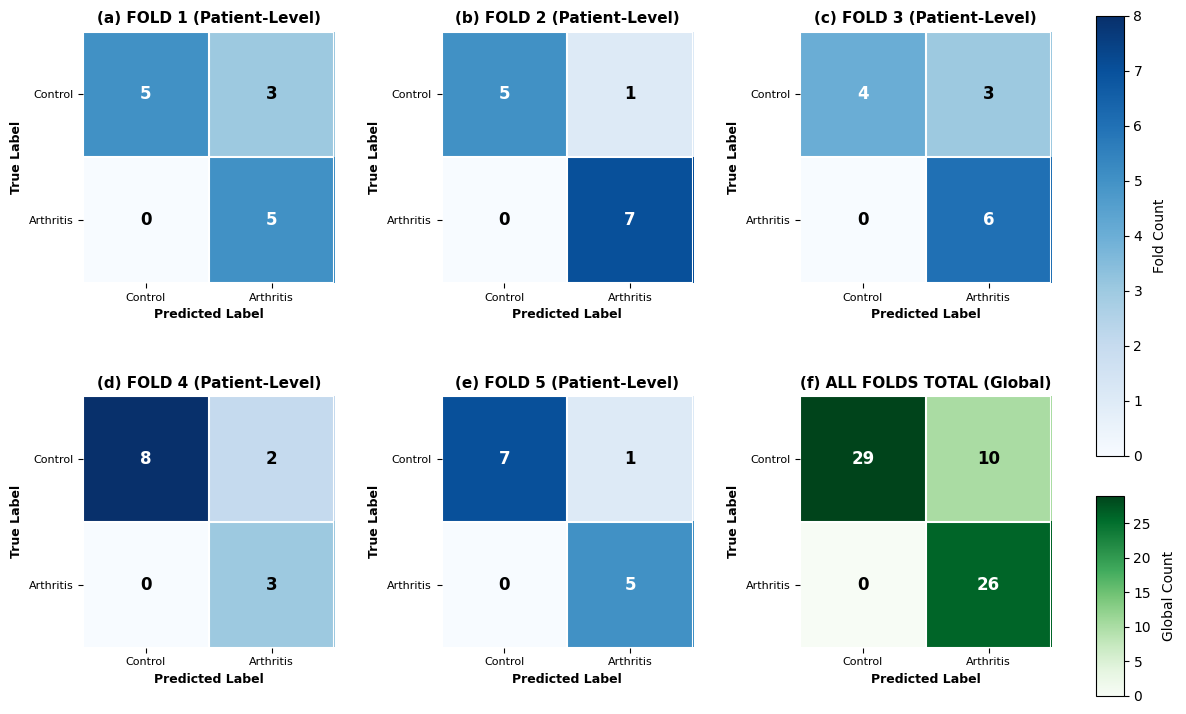

Saved: artifacts/confusion_matrix_patient_grid.png


In [7]:
def plot_confusion_grid_from_summaries(summaries: List[Dict[str, object]], save_path: Path) -> Path:
    if not summaries:
        raise ValueError("summaries is empty")

    fold_mats = []
    for summary in summaries:
        cm = summary["confusion_matrix"]
        matrix = np.array([[cm["tn"], cm["fp"]], [cm["fn"], cm["tp"]]], dtype=int)
        fold_mats.append((int(summary["fold_id"]), matrix))

    total_matrix = np.sum([matrix for _, matrix in fold_mats], axis=0)
    fold_vmax = max(int(matrix.max()) for _, matrix in fold_mats)
    total_vmax = int(total_matrix.max())

    fig, axes = plt.subplots(2, 3, figsize=(14, 8))
    axes = axes.flatten()

    def draw_matrix(ax, matrix, title, cmap, vmax):
        im = ax.imshow(matrix, cmap=cmap, vmin=0, vmax=max(vmax, 1))
        ax.set_title(title, fontsize=11, fontweight="bold")
        ax.set_xticks([0, 1], labels=["Control", "Arthritis"])
        ax.set_yticks([0, 1], labels=["Control", "Arthritis"])
        ax.set_xlabel("Predicted Label", fontsize=9, fontweight="bold")
        ax.set_ylabel("True Label", fontsize=9, fontweight="bold")
        ax.tick_params(labelsize=8)

        threshold = max(vmax, 1) * 0.5
        for row in range(2):
            for col in range(2):
                value = int(matrix[row, col])
                color = "white" if value >= threshold else "black"
                ax.text(col, row, str(value), ha="center", va="center", fontsize=12, fontweight="bold", color=color)

        for spine in ax.spines.values():
            spine.set_visible(False)
        ax.set_xticks(np.arange(-0.5, 2, 1), minor=True)
        ax.set_yticks(np.arange(-0.5, 2, 1), minor=True)
        ax.grid(which="minor", color="white", linestyle="-", linewidth=1.5)
        ax.tick_params(which="minor", bottom=False, left=False)
        return im

    labels = [chr(ord("a") + i) for i in range(len(fold_mats) + 1)]
    for idx, (fold_id, matrix) in enumerate(fold_mats):
        draw_matrix(axes[idx], matrix, f"({labels[idx]}) FOLD {fold_id} (Patient-Level)", "Blues", fold_vmax)

    draw_matrix(axes[-1], total_matrix, f"({labels[len(fold_mats)]}) ALL FOLDS TOTAL (Global)", "Greens", total_vmax)

    for ax in axes[len(fold_mats):-1]:
        ax.axis("off")

    blue_norm = plt.Normalize(vmin=0, vmax=max(fold_vmax, 1))
    green_norm = plt.Normalize(vmin=0, vmax=max(total_vmax, 1))
    sm_blue = plt.cm.ScalarMappable(cmap="Blues", norm=blue_norm)
    sm_blue.set_array([])
    sm_green = plt.cm.ScalarMappable(cmap="Greens", norm=green_norm)
    sm_green.set_array([])

    # Fixed colorbar placement — subplot'lara overlap etmez
    fig.subplots_adjust(right=0.82, hspace=0.45, wspace=0.4)

    cax_blue = fig.add_axes([0.85, 0.35, 0.02, 0.55])
    cbar_blue = fig.colorbar(sm_blue, cax=cax_blue)
    cbar_blue.ax.set_ylabel("Fold Count", rotation=90, labelpad=8)

    cax_green = fig.add_axes([0.85, 0.05, 0.02, 0.25])
    cbar_green = fig.colorbar(sm_green, cax=cax_green)
    cbar_green.ax.set_ylabel("Global Count", rotation=90, labelpad=8)

    save_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    return save_path


cm_grid_path = plot_confusion_grid_from_summaries(
    summaries,
    Path(CONFIG.artifacts_dir) / "confusion_matrix_patient_grid.png",
)
print(f"Saved: {cm_grid_path}")
